In [ ]:
#Lab 3. Logistic Regression
#Given a suitable classification dataset:
#a) Identify the input features and target variable and split the dataset into training and testing sets.
#b) Build and train a Logistic Regression model.
#c) Explain the role of the sigmoid function in converting the model output into probability.
#d) Predict class labels and class probabilities for the test data and explain the role of the classification threshold.
#e) Evaluate the model using a confusion matrix and suitable classification measures.
#f) Plot the ROC curve and calculate AUC, where applicable.
#g) Change the classification threshold, observe its effect on predictions, and use the trained model to classify a new observation.



In [2]:
#a) Identify the input features and target variable and split the dataset into training and testing sets.

import pandas as pd
from sklearn.model_selection import train_test_split

# Load Dataset 3
df = pd.read_csv("03_email_spam.csv")

# Input features (X)
# We remove the target column "is_spam"
X = df.drop("is_spam", axis=1)

# Target variable (y)
# 0 = Not Spam
# 1 = Spam
y = df["is_spam"]

# Convert categorical columns into numerical columns
# Logistic Regression works with numerical data
X = pd.get_dummies(X, drop_first=True)

# Split the dataset
# 80% data is used for training
# 20% data is used for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Display the size of training and testing data
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (240, 11)
Testing data: (60, 11)


In [3]:
#b) Build and train a Logistic Regression model.

from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
model = LogisticRegression(max_iter=1000)

# Train the model using training data
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully")

Logistic Regression model trained successfully


In [4]:
#c) Explain the role of the sigmoid function in converting the model output into probability.

# Logistic Regression uses the Sigmoid function.
# Sigmoid converts the model output into a probability between 0 and 1.
#
# Probability close to 1 -> higher chance of Spam
# Probability close to 0 -> higher chance of Not Spam

# Get probabilities for test data
probabilities = model.predict_proba(X_test)

# Display first 5 probability results
print("Probabilities:")
print(probabilities[:5])

Probabilities:
[[0.60256943 0.39743057]
 [0.34625173 0.65374827]
 [0.5828398  0.4171602 ]
 [0.4404803  0.5595197 ]
 [0.5843151  0.4156849 ]]


In [5]:
#d) Predict class labels and class probabilities for the test data and explain the role of the classification threshold.

# Predict class labels
# 0 = Not Spam
# 1 = Spam
y_pred = model.predict(X_test)

# Get probability of Spam
# [:, 1] selects the probability of class 1 (Spam)
y_prob = model.predict_proba(X_test)[:, 1]

print("Predicted class labels:")
print(y_pred[:10])

print("\nProbability of Spam:")
print(y_prob[:10])

# Classification threshold
# Default threshold = 0.50
#
# If probability >= 0.50 -> Spam (1)
# If probability < 0.50 -> Not Spam (0)

threshold = 0.50

threshold_predictions = (y_prob >= threshold).astype(int)

print("\nPredictions using threshold 0.50:")
print(threshold_predictions[:10])

Predicted class labels:
[0 1 0 1 0 0 0 1 0 0]

Probability of Spam:
[0.39743057 0.65374827 0.4171602  0.5595197  0.4156849  0.44962265
 0.29251339 0.53799783 0.10311631 0.49880396]

Predictions using threshold 0.50:
[0 1 0 1 0 0 0 1 0 0]


In [6]:
#e) Evaluate the model using a confusion matrix and suitable classification measures.

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Calculate Precision
precision = precision_score(y_test, y_pred)

# Calculate Recall
recall = recall_score(y_test, y_pred)

# Calculate F1-Score
f1 = f1_score(y_test, y_pred)

print("\nAccuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

Confusion Matrix:
[[23 12]
 [ 8 17]]

Accuracy: 0.6666666666666666
Precision: 0.5862068965517241
Recall: 0.68
F1-Score: 0.6296296296296297


AUC Score: 0.734857142857143


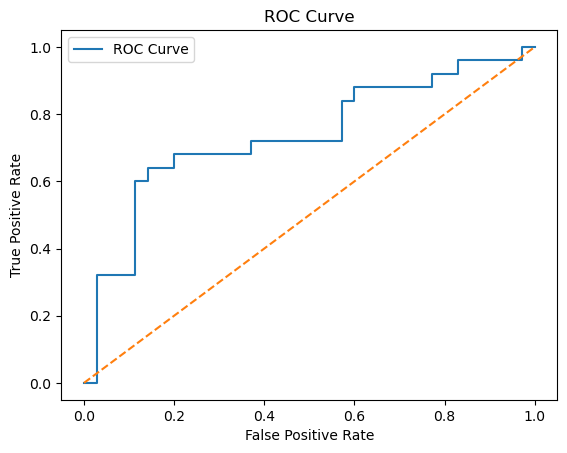

In [7]:
#f) Plot the ROC curve and calculate AUC, where applicable.

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate False Positive Rate and True Positive Rate
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC score
auc = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc)

# Plot ROC Curve
plt.plot(fpr, tpr, label="ROC Curve")

# Plot reference line
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [8]:
#g) Change the classification threshold, observe its effect on predictions, and use the trained model to classify a new observation.

# Change the threshold from 0.50 to 0.70
# Now probability must be 0.70 or more to classify as Spam

new_threshold = 0.70

new_threshold_predictions = (y_prob >= new_threshold).astype(int)

print("Predictions using threshold 0.70:")
print(new_threshold_predictions[:10])


# Create a new observation
# Values are based on the columns in Dataset 3

new_observation = pd.DataFrame({
    "num_links": [10],
    "num_caps_words": [15],
    "has_attachment": [1],
    "sender_reputation_score": [8.0],
    "device_type": ["Phone"],
    "os_type": ["Android"],
    "subscription_type": ["Premium"]
})

# Convert categorical values into numerical columns
new_observation = pd.get_dummies(new_observation, drop_first=True)

# Make sure the new observation has the same columns
# as the training data
new_observation = new_observation.reindex(
    columns=X_train.columns,
    fill_value=0
)

# Find probability of Spam
new_probability = model.predict_proba(new_observation)[0][1]

# Use 0.50 threshold
new_prediction = int(new_probability >= 0.50)

print("\nNew Observation Probability of Spam:", new_probability)
print("New Observation Prediction:", new_prediction)

# 0 = Not Spam
# 1 = Spam


Predictions using threshold 0.70:
[0 0 0 0 0 0 0 0 0 0]

New Observation Probability of Spam: 0.46818412509137153
New Observation Prediction: 0
